# Electricity Load Forecasting: Linear Regression Baseline

In this notebook, we load our preprocessed time-series data and train a Linear Regression model. This will serve as our baseline to establish how well standard autoregressive features (lags and rolling means) predict future electricity consumption.

## 1. Imports, Data Loading and Client Selection
We import pandas for data handling, and scikit-learn for our model, metrics, and data splitting.

We load the highly compressed Parquet file. To evaluate the model clearly and avoid overwhelming system memory during this baseline test, we will filter the dataset to isolate 30 client.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# ---------------------------------------------------------
# Load Data and Sample Clients
# ---------------------------------------------------------
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

random.seed(42)
all_clients = sorted(df_long['ClientID'].unique().tolist())
sampled_clients = random.sample(all_clients, 30)

print(f"Filtering data for {len(sampled_clients)} sampled clients...")
df_sample = df_long[df_long['ClientID'].isin(sampled_clients)].copy()

Loading processed data...
Filtering data for 30 sampled clients...


## 2. Data Preparation and Chronological Train/Test Split
Machine learning models require numerical inputs. We convert our boolean holiday/weekend flags to integers (0 and 1). Furthermore, cyclical categorical variables like 'Hour' and 'Weekday' must be One-Hot Encoded so the model doesn't assume that Hour 2 is twice as large as Hour 1.
When working with time-series data, we can **never** randomly shuffle and split our data. We must respect the flow of time to prevent "data leakage" (peeking into the future to predict the past). We will use data prior to 2014 for training, and data from 2014 onwards for testing.

In [2]:
# ---------------------------------------------------------
# Feature Engineering and Train/Test Split
# ---------------------------------------------------------
df_sample['Is_Weekend'] = df_sample['Is_Weekend'].astype(int)
df_sample['Is_Holiday'] = df_sample['Is_Holiday'].astype(int)

df_model = pd.get_dummies(df_sample, columns=['Hour', 'Weekday', 'Consumer_Category'], drop_first=True)

cutoff_date = df_model['Date'].max() - pd.Timedelta(hours=24)
train = df_model[df_model['Date'] < cutoff_date].copy()
test  = df_model[df_model['Date'] >= cutoff_date].copy()

# ---------------------------------------------------------
# Per-Client Standardization
# ---------------------------------------------------------
weather_cols = ['Temp_National_Avg', 'HDH', 'CDH']
scaler_weather = StandardScaler()
train[weather_cols] = scaler_weather.fit_transform(train[weather_cols])
test[weather_cols]  = scaler_weather.transform(test[weather_cols])

train = train.sort_values(by=['ClientID', 'Date'])
test  = test.sort_values(by=['ClientID', 'Date'])

for col in ['Lag_15min_Scaled', 'Lag_24h_Scaled', 'Rolling_Mean_4h_Scaled']:
    train[col] = np.nan
    test[col]  = np.nan

client_scalers = {}

for client in sampled_clients:
    scaler = StandardScaler()
    train_mask = train['ClientID'] == client
    test_mask  = test['ClientID'] == client

    if not train_mask.any():
        print(f"Warning: Client {client} has no data in the train set. Skipping...")
        continue

    train.loc[train_mask, 'Consumption_Scaled'] = scaler.fit_transform(
        train.loc[train_mask, 'Consumption'].values.reshape(-1, 1)
    ).flatten()

    train.loc[train_mask, 'Lag_15min_Scaled']    = train.loc[train_mask, 'Consumption_Scaled'].shift(1)
    train.loc[train_mask, 'Lag_24h_Scaled']      = train.loc[train_mask, 'Consumption_Scaled'].shift(96)
    train.loc[train_mask, 'Rolling_Mean_4h_Scaled'] = train.loc[train_mask, 'Consumption_Scaled'].rolling(window=16).mean()

    if test_mask.any():
        test.loc[test_mask, 'Consumption_Scaled'] = scaler.transform(
            test.loc[test_mask, 'Consumption'].values.reshape(-1, 1)
        ).flatten()

    client_scalers[client] = scaler

train = train.dropna(subset=['Consumption_Scaled', 'Lag_15min_Scaled', 'Lag_24h_Scaled', 'Rolling_Mean_4h_Scaled'])

# ---------------------------------------------------------
# Build Feature Matrices
# ---------------------------------------------------------
cols_to_drop = ['Date', 'ClientID', 'DayMonth', 'Consumption', 'Consumption_Scaled',
                'Lag_15min', 'Lag_24h', 'Rolling_Mean_4h']
cols_to_drop = [c for c in cols_to_drop if c in train.columns]

X_train = train.drop(columns=cols_to_drop)
y_train = train['Consumption_Scaled']

test    = test.sort_values(by=['ClientID', 'Date'])
X_test  = test.drop(columns=cols_to_drop)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

Training shape: (3200514, 39)
Testing shape:  (2910, 39)


## 3. Model Training and Evaluation
We train the Linear Regression model on our historical data. We evaluate its performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to understand our average prediction error in kilowatts (kW).

In [3]:
# ---------------------------------------------------------
# Model Training
# ---------------------------------------------------------
print("Training Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)

Training Linear Regression model...


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [4]:
print("Making recursive predictions on test set...")

# Create an empty column in the test dataframe to save the step-by-step predictions
test['Predicted_Consumption_Scaled'] = np.nan

# Iterate over each individual client
for client in tqdm(sampled_clients, desc="Predicting clients"):
    
    # Skip if the client has no scaler (e.g., they had no training data)
    if client not in client_scalers:
        continue
        
    # Test row indices for this client
    client_test_idx = test[test['ClientID'] == client].index
    
    # Skip if the client has no test data
    if len(client_test_idx) == 0:
        continue
        
    # Get the last 96 ACTUAL training values (24 hours * 4 15-min steps = 96) 
    storico_reale = train[train['ClientID'] == client].sort_values('Date')['Consumption_Scaled'].tail(96).tolist()
    history_buffer = storico_reale.copy()
    
    # Work on a small sub-dataframe for just this client
    X_client = X_test.loc[client_test_idx].copy()
    
    # Find the numerical positions of the columns for maximum speed
    idx_lag15 = X_client.columns.get_loc('Lag_15min_Scaled')
    idx_lag24 = X_client.columns.get_loc('Lag_24h_Scaled')
    idx_roll4h = X_client.columns.get_loc('Rolling_Mean_4h_Scaled')
    
    predictions = []
    
    for i in range(len(X_client)):
        lag_15  = history_buffer[-1]  if len(history_buffer) >= 1  else np.nan
        lag_24  = history_buffer[-96] if len(history_buffer) >= 96 else np.nan
        roll_4h = np.mean(history_buffer[-16:]) if len(history_buffer) >= 16 else np.nan
        
        X_client.iat[i, idx_lag15]  = lag_15
        X_client.iat[i, idx_lag24]  = lag_24
        X_client.iat[i, idx_roll4h] = roll_4h
        
        X_current = X_client.iloc[[i]]
        pred = model.predict(X_current)[0]
        
        predictions.append(pred)
        history_buffer.append(pred)
        
    test.loc[client_test_idx, 'Predicted_Consumption_Scaled'] = predictions


# ---------------------------------------------------------
# Evaluation in raw kW (inverse-transform per client)
# ---------------------------------------------------------
print("\nEvaluating model (raw kW)...")

all_maes_kw   = []
all_rmses_kw  = []
all_mapes_kw  = []
all_wmapes_kw = []
client_results = []

for client in sampled_clients:
    if client not in client_scalers:
        continue
    
    client_mask = test['ClientID'] == client
    client_data = test[client_mask].copy()
    
    valid = client_data['Consumption'].notna() & client_data['Predicted_Consumption_Scaled'].notna()
    if valid.sum() == 0:
        continue

    y_true_kw = client_data.loc[valid, 'Consumption'].values
    
    scaler = client_scalers[client]
    y_pred_kw = scaler.inverse_transform(
        client_data.loc[valid, 'Predicted_Consumption_Scaled'].values.reshape(-1, 1)
    ).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0)

    mae  = np.mean(np.abs(y_true_kw - y_pred_kw))
    rmse = np.sqrt(np.mean((y_true_kw - y_pred_kw) ** 2))

    nonzero = y_true_kw > 0.1
    mape  = np.mean(np.abs((y_true_kw[nonzero] - y_pred_kw[nonzero]) / y_true_kw[nonzero])) if nonzero.sum() > 0 else 0.0
    sum_actual = np.sum(y_true_kw)
    wmape = np.sum(np.abs(y_true_kw - y_pred_kw)) / sum_actual if sum_actual > 0 else 0.0

    all_maes_kw.append(mae)
    all_rmses_kw.append(rmse)
    all_mapes_kw.append(mape)
    all_wmapes_kw.append(wmape)
    client_results.append({'ClientID': client, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'WMAPE': wmape})

print("--- LINEAR REGRESSION BENCHMARK RESULTS ---")
print(f"Average MAPE:  {np.mean(all_mapes_kw):.2%}")
print(f"Average WMAPE: {np.mean(all_wmapes_kw):.2%}")
print(f"Average MAE:   {np.mean(all_maes_kw):.2f} kW")
print(f"Average RMSE:  {np.mean(all_rmses_kw):.2f} kW")

# ---------------------------------------------------------
# Performance Breakdown by Cluster
# ---------------------------------------------------------
cluster_map = pd.read_csv('../Datasets/client_clusters.csv')
lr_results_df = pd.DataFrame(client_results)
lr_results_df = lr_results_df.merge(cluster_map, on='ClientID')

print("\n--- LINEAR REGRESSION PERFORMANCE BY CLUSTER ---\n")
summary = lr_results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    MAE=('MAE', 'mean'),
    RMSE=('RMSE', 'mean'),
    MAPE=('MAPE', 'mean'),
    WMAPE=('WMAPE', 'mean')
).round(3)
summary['MAPE']  = summary['MAPE'].map('{:.1%}'.format)
summary['WMAPE'] = summary['WMAPE'].map('{:.1%}'.format)
print(summary.to_string())

Making recursive predictions on test set...


Predicting clients: 100%|██████████| 30/30 [00:01<00:00, 21.35it/s]


Evaluating model (raw kW)...
--- LINEAR REGRESSION BENCHMARK RESULTS ---
Average MAPE:  649.84%
Average WMAPE: 39.41%
Average MAE:   35.75 kW
Average RMSE:  50.19 kW

--- LINEAR REGRESSION PERFORMANCE BY CLUSTER ---

         n_clients     MAE    RMSE     MAPE  WMAPE
Cluster                                           
0                2  63.546  77.929    12.7%   8.2%
1                7  53.443  86.704    33.2%  23.4%
2                6  26.893  35.287    16.6%  16.6%
3                6   9.443  11.631    22.3%  22.2%
4                9  39.262  51.259  2111.6%  85.5%


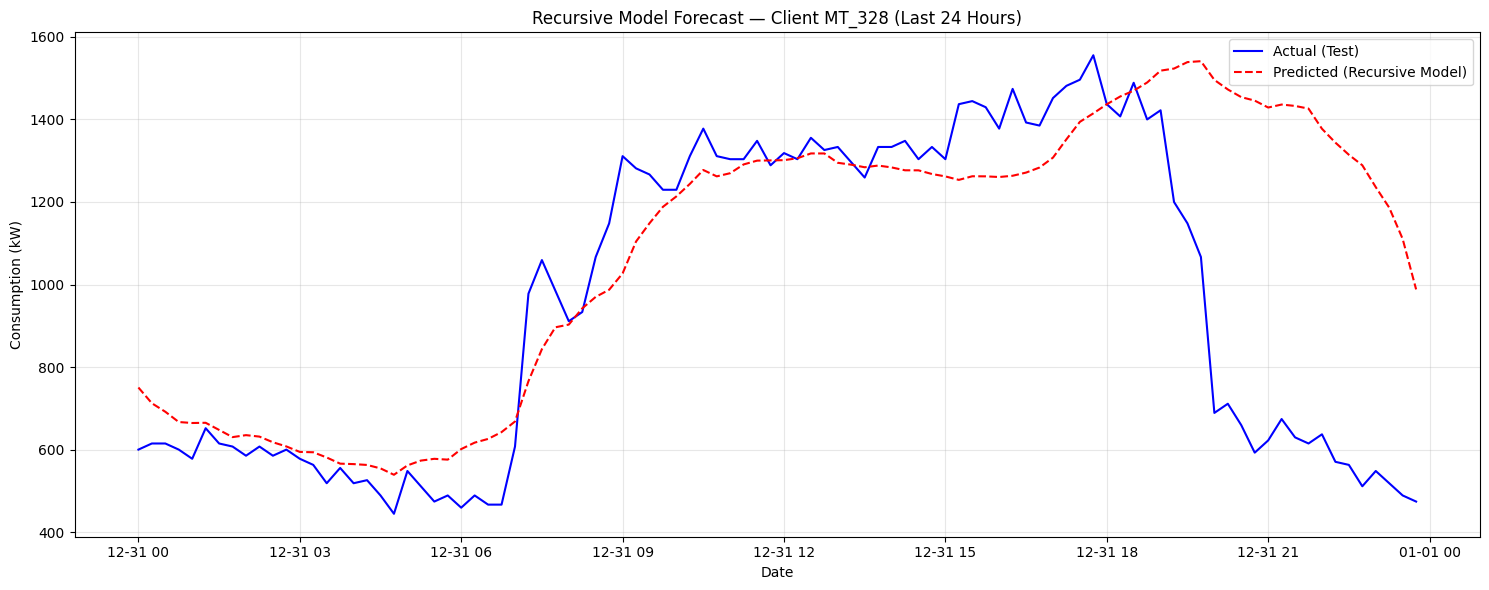

In [5]:
# Get the first client that actually has predictions (is in our scalers dictionary)
test_client_id = next(client for client in sampled_clients if client in client_scalers)

# Extract just this client's data from the test set
client_test_data = test[test['ClientID'] == test_client_id].copy()

# The real, unscaled kW values are already in the original 'Consumption' column
client_y_actual_kw = client_test_data['Consumption'] 

# Get the scaled predictions we just calculated
client_y_pred_scaled = client_test_data['Predicted_Consumption_Scaled']

# DO NOT refit a new scaler. Retrieve the exact scaler we already trained and saved for this client!
client_scaler = client_scalers[test_client_id]

# Inverse transform the predictions back to real kW
client_y_pred_kw = client_scaler.inverse_transform(client_y_pred_scaled.values.reshape(-1, 1)).flatten()

# Days to plot: 3 days * 24 hours * 4 intervals per hour = 288 steps
steps_to_plot = 96

plt.figure(figsize=(15, 6))

# Plot Actuals
plt.plot(
    client_test_data['Date'].iloc[:steps_to_plot], 
    client_y_actual_kw.iloc[:steps_to_plot], 
    label='Actual (Test)', 
    color='blue'
)

# Plot Predictions
plt.plot(
    client_test_data['Date'].iloc[:steps_to_plot], 
    client_y_pred_kw[:steps_to_plot], 
    label='Predicted (Recursive Model)', 
    color='red', 
    linestyle='--'
)

plt.title(f'Recursive Model Forecast — Client {test_client_id} (Last 24 Hours)')
plt.xlabel('Date')
plt.ylabel('Consumption (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures labels don't get cut off
plt.show()

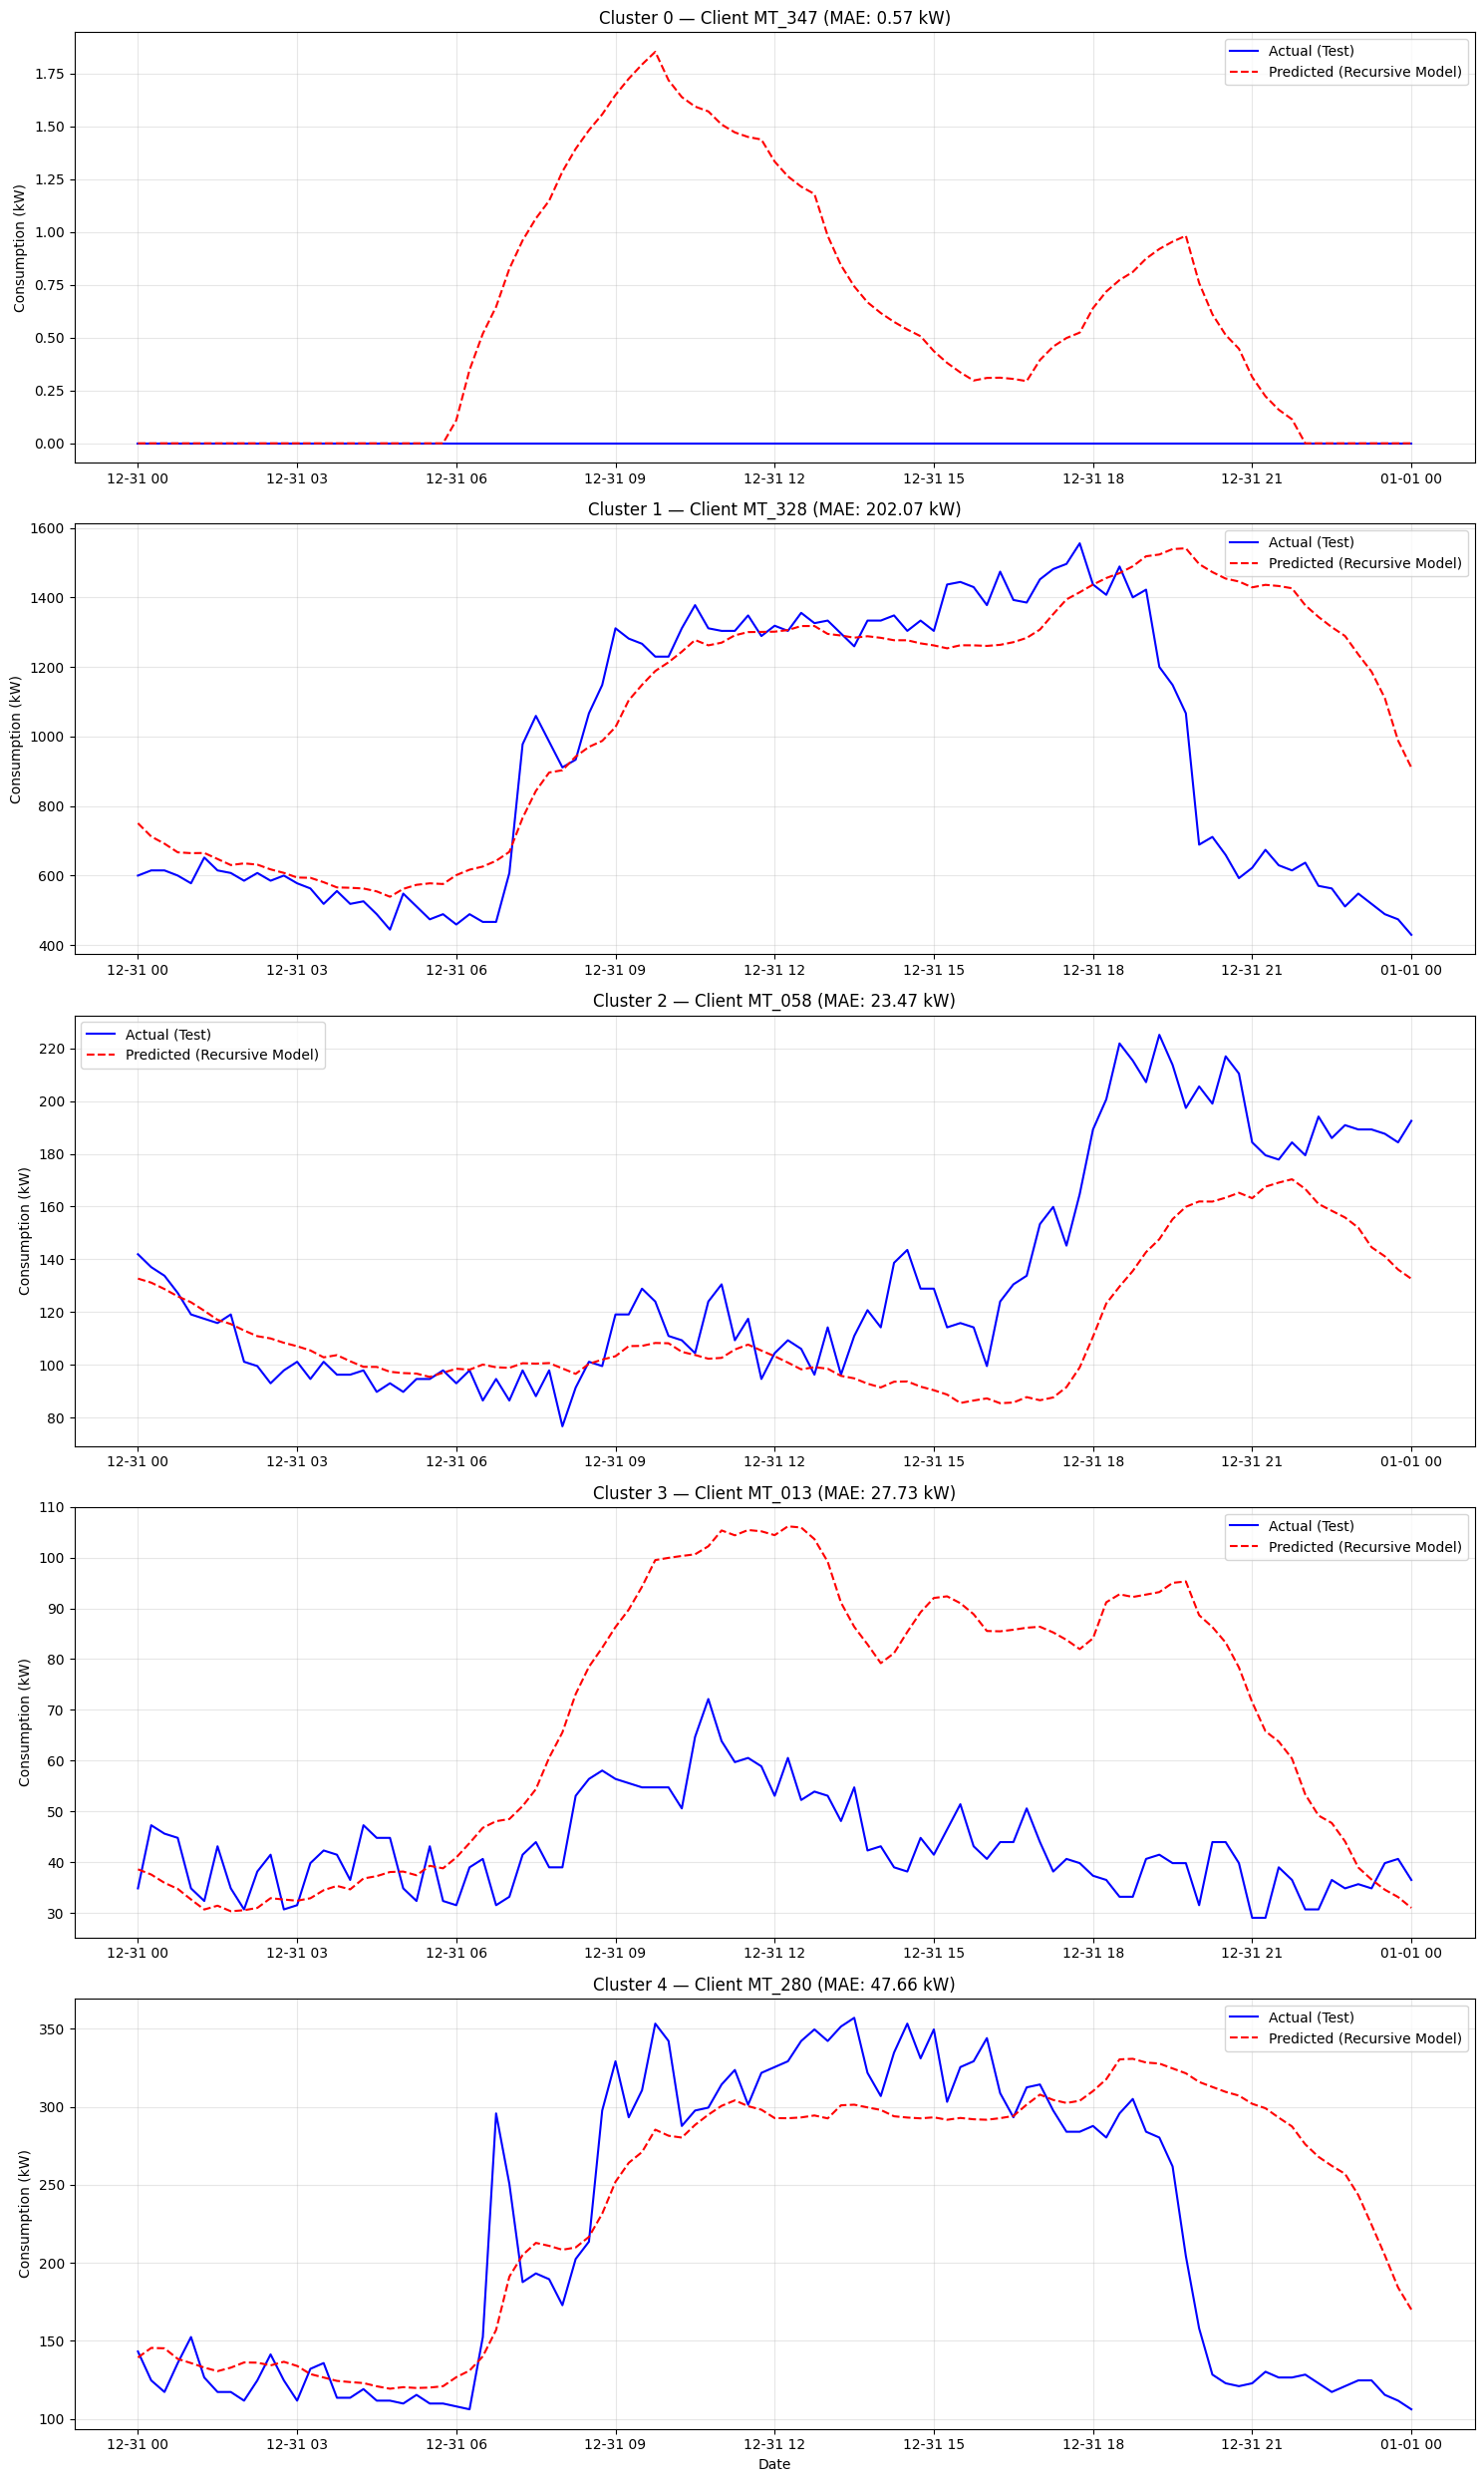

In [6]:
# ---------------------------------------------------------
# Visualization: One Client per Cluster
# ---------------------------------------------------------
cluster_representatives = (
    lr_results_df.groupby('Cluster')['ClientID'].first().to_dict()
)

fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(15, 5 * len(cluster_representatives)))

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx] if len(cluster_representatives) > 1 else axes

    client_data = test[test['ClientID'] == client_id].copy()
    y_actual_kw = client_data['Consumption'].values

    scaler = client_scalers[client_id]
    y_pred_kw = scaler.inverse_transform(
        client_data['Predicted_Consumption_Scaled'].values.reshape(-1, 1)
    ).flatten()
    y_pred_kw = np.maximum(y_pred_kw, 0)

    client_mae = lr_results_df[lr_results_df['ClientID'] == client_id]['MAE'].values[0]

    ax.plot(client_data['Date'].values, y_actual_kw,
            label='Actual (Test)', color='blue')
    ax.plot(client_data['Date'].values, y_pred_kw,
            label='Predicted (Recursive Model)', color='red', linestyle='--')

    ax.set_title(f'Cluster {cluster_id} — Client {client_id} (MAE: {client_mae:.2f} kW)')
    ax.set_ylabel('Consumption (kW)')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()